In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, NodeRFModel, NodeLSTMModel, GATv2Model

disease_name    = 'measles'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2017-06-01'
split_valtest   = '2018-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    # log_transform       = ['incidence','population_size'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    
# data_orchestrator = DataOrchestrator(config).build()


data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )



/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataorchestrator    = (DataOrchestrator(config).build())
shallowdata         = ShallowDataLoaderManager(dataorchestrator).construct_dataloaders()
graphdataloader_id  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('identity_graph').construct_dataloaders()
graphdataloader_bn  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('geographical_neighbors1').construct_dataloaders()


==                     lstm                     ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.1828, val loss: 0.1092 ✓ (new best)
Epoch 2 train loss: 0.1564, val loss: 0.0989 ✓ (new best)
Epoch 3 train loss: 0.1236, val loss: 0.0909 ✓ (new best)
Epoch 4 train loss: 0.1073, val loss: 0.0919 (patience: 1/20)
Epoch 5 train loss: 0.1042, val loss: 0.0925 (patience: 2/20)
Epoch 6 train loss: 0.1034, val loss: 0.0924 (patience: 3/20)
Epoch 7 train loss: 0.1022, val loss: 0.0924 (patience: 4/20)
Epoch 8 train loss: 0.1001, val loss: 0.0922 (patience: 5/20)
Epoch 9 train loss: 0.0992, val loss: 0.0919 (patience: 6/20)
Epoch 10 train loss: 0.0982, val loss: 0.0915 (patience: 7/20)
lr has been updated from 1.00e-04 to 5.00e-05
Epoch 11 train loss: 0.0969, val loss: 0.0913 (patience: 8/20)
Epoch 12 train loss: 0.0956, val loss: 0.0912 (patience: 9/20)
Epoch 13 train loss: 0.0951, val loss: 0.0910 (patience: 10/20)
Epoc

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 450.88it/s]

Test loss: 0.0834
additonal transformation


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

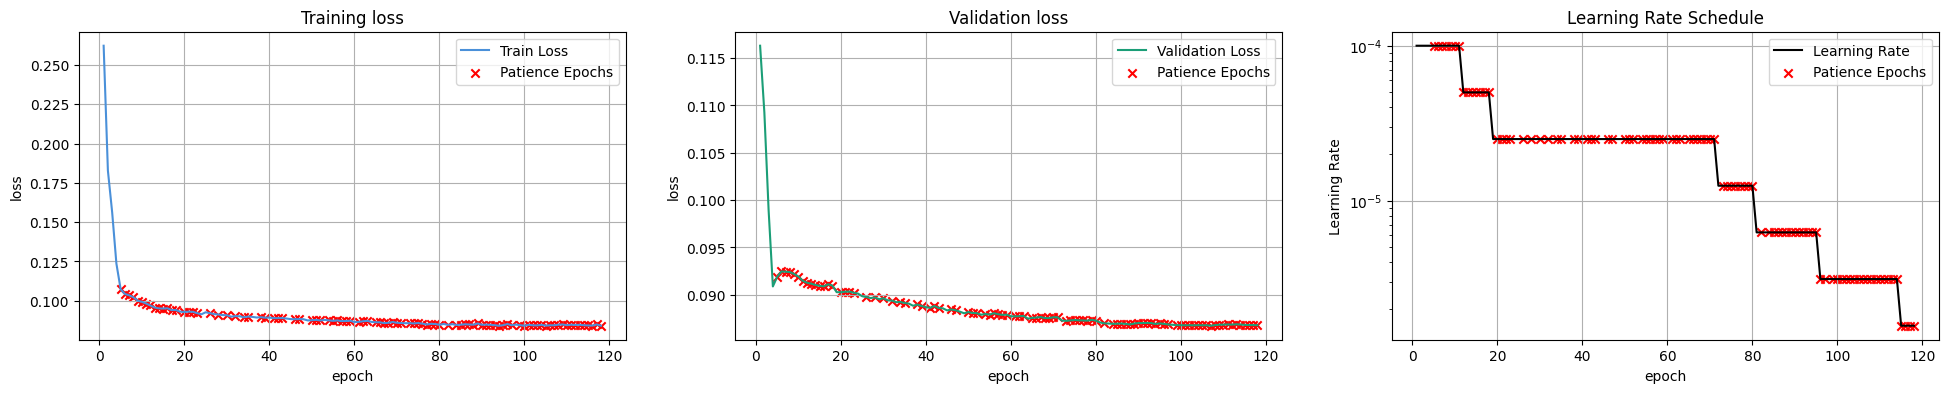

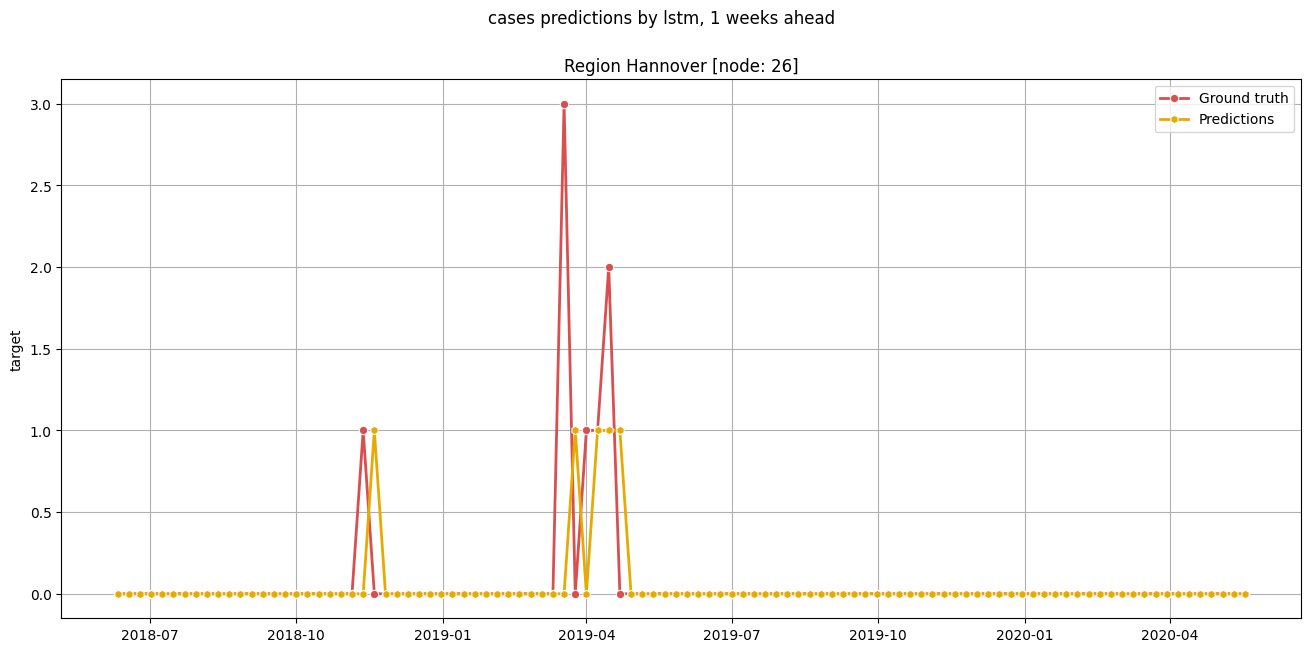

In [3]:
n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'poisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


lstm = NodeLSTMModel(graphdataloader_id, name = 'lstm')
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train(verbose = 2)
lstm.forecast('test')
lstm.show_forecasts(26)


==                   gcn - bn                   ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.2038, val loss: 0.1123 ✓ (new best)
Epoch 2 train loss: 0.1596, val loss: 0.1038 ✓ (new best)
Epoch 3 train loss: 0.1383, val loss: 0.1003 ✓ (new best)
Epoch 4 train loss: 0.1278, val loss: 0.0989 ✓ (new best)
Epoch 5 train loss: 0.1248, val loss: 0.0984 ✓ (new best)
Epoch 6 train loss: 0.1232, val loss: 0.0981 ✓ (new best)
Epoch 7 train loss: 0.1228, val loss: 0.0977 ✓ (new best)
Epoch 8 train loss: 0.1222, val loss: 0.0974 ✓ (new best)
Epoch 9 train loss: 0.1216, val loss: 0.0971 ✓ (new best)
Epoch 10 train loss: 0.1191, val loss: 0.0967 ✓ (new best)
Epoch 11 train loss: 0.1196, val loss: 0.0964 ✓ (new best)
Epoch 12 train loss: 0.1174, val loss: 0.0961 ✓ (new best)
Epoch 13 train loss: 0.1175, val loss: 0.0958 ✓ (new best)
Epoch 14 train loss: 0.1167, val loss: 0.0955 ✓ (new best)
Epoch 15 train loss: 0.1162, v

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 616.30it/s]


Test loss: 0.0812
additonal transformation


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

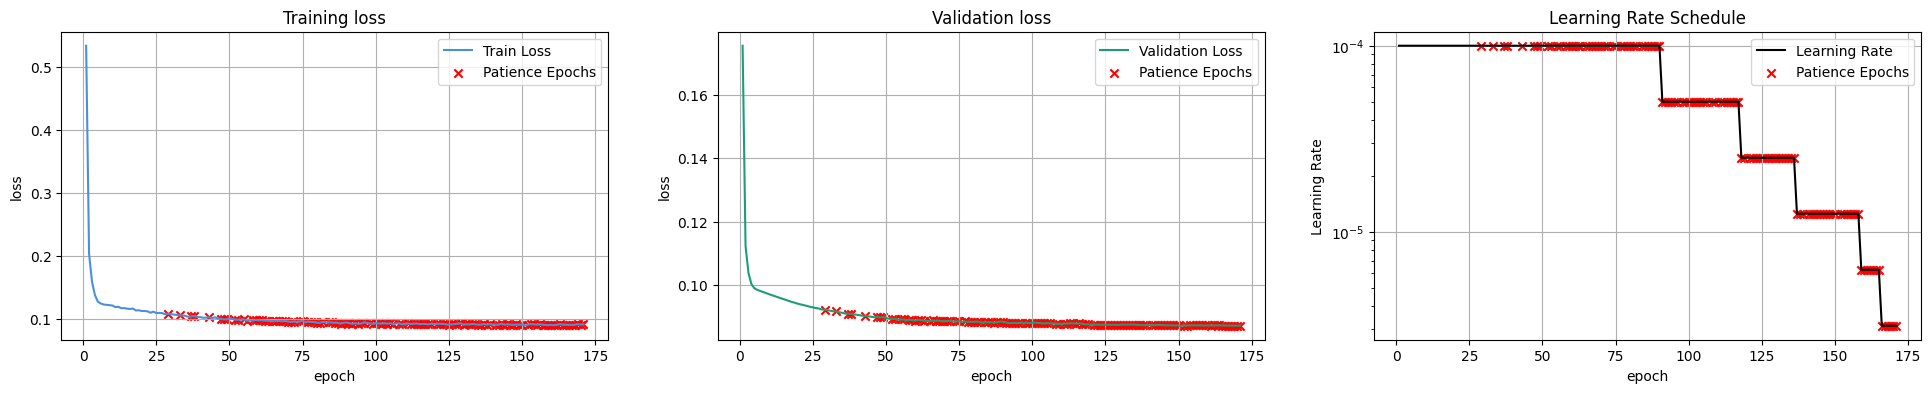

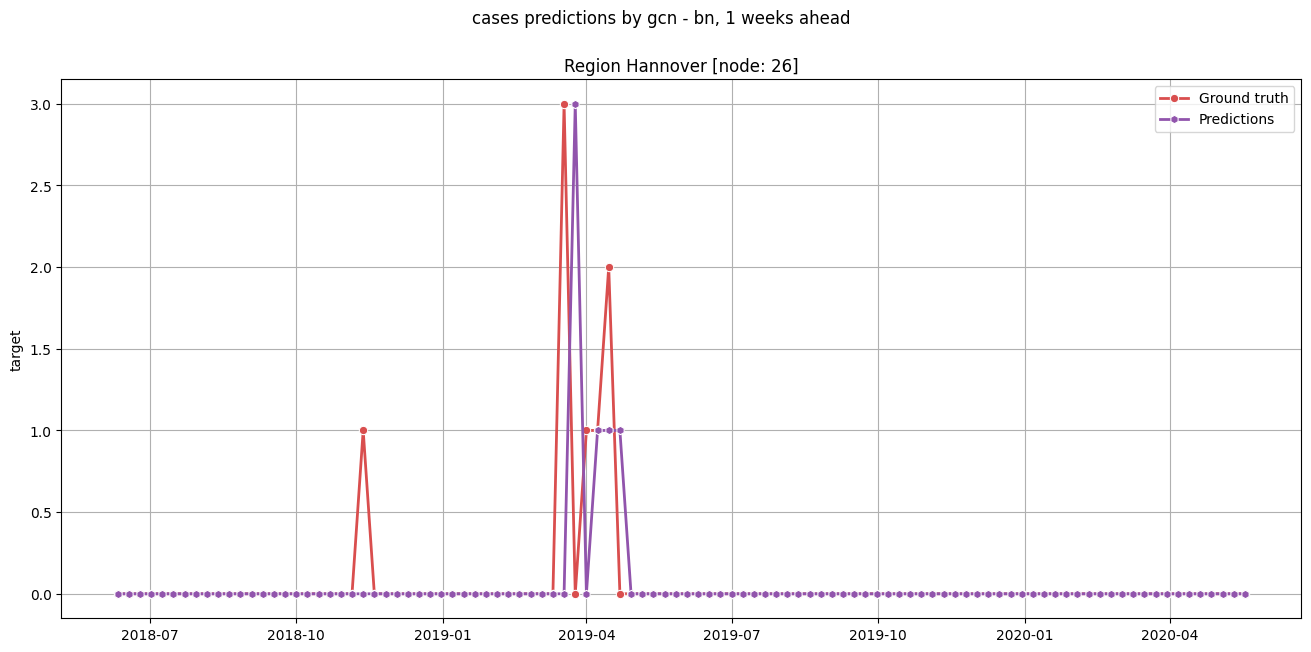

In [4]:
from src.models import SpatialGNNModel

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'poisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


gcn = SpatialGNNModel(graphdataloader_bn, name = 'gcn - bn')
gcn.set_model_hparams()
gcn.set_global_hparams(**global_hparams)
gcn.train(verbose = 2)
gcn.forecast('test')
gcn.show_forecasts(26)


==                   gcn - bn                   ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.1723, val loss: 0.1067 ✓ (new best)
Epoch 2 train loss: 0.1509, val loss: 0.1017 ✓ (new best)
Epoch 3 train loss: 0.1385, val loss: 0.0985 ✓ (new best)
Epoch 4 train loss: 0.1306, val loss: 0.0966 ✓ (new best)
Epoch 5 train loss: 0.1260, val loss: 0.0957 ✓ (new best)
Epoch 6 train loss: 0.1234, val loss: 0.0952 ✓ (new best)
Epoch 7 train loss: 0.1208, val loss: 0.0950 ✓ (new best)
Epoch 8 train loss: 0.1197, val loss: 0.0947 ✓ (new best)
Epoch 9 train loss: 0.1190, val loss: 0.0944 ✓ (new best)
Epoch 10 train loss: 0.1168, val loss: 0.0942 ✓ (new best)
Epoch 11 train loss: 0.1159, val loss: 0.0939 ✓ (new best)
Epoch 12 train loss: 0.1156, val loss: 0.0936 ✓ (new best)
Epoch 13 train loss: 0.1139, val loss: 0.0933 ✓ (new best)
Epoch 14 train loss: 0.1124, val loss: 0.0930 ✓ (new best)
Epoch 15 train loss: 0.1109, v

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 618.49it/s]


Test loss: 0.0837
additonal transformation


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

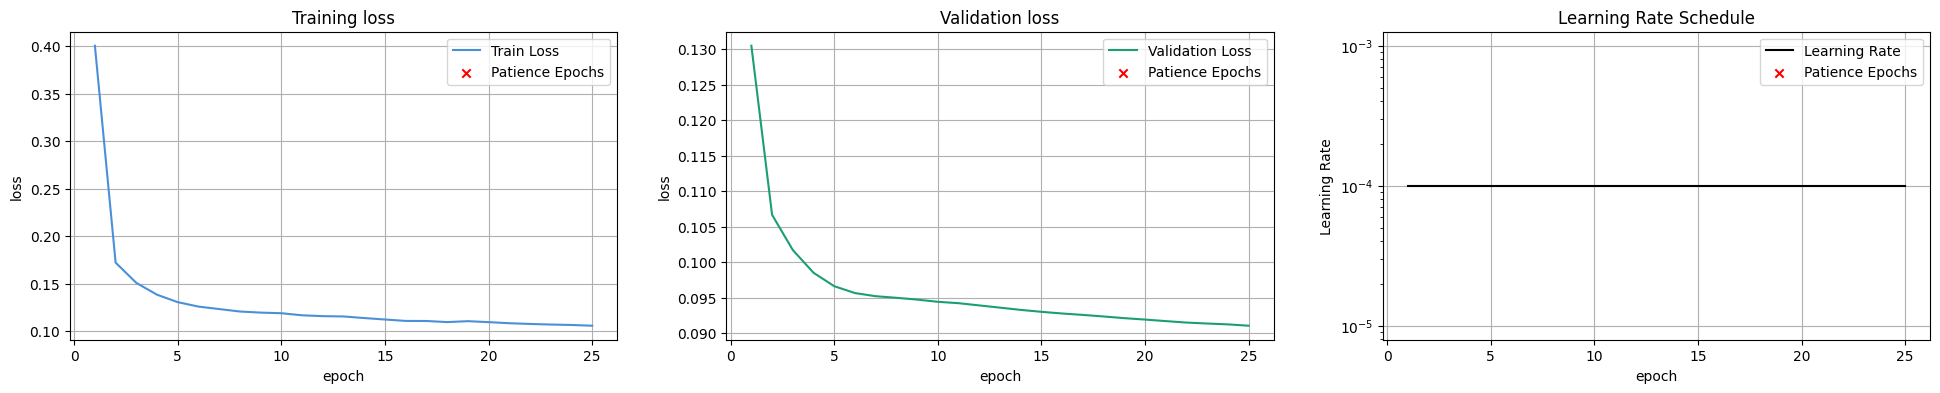

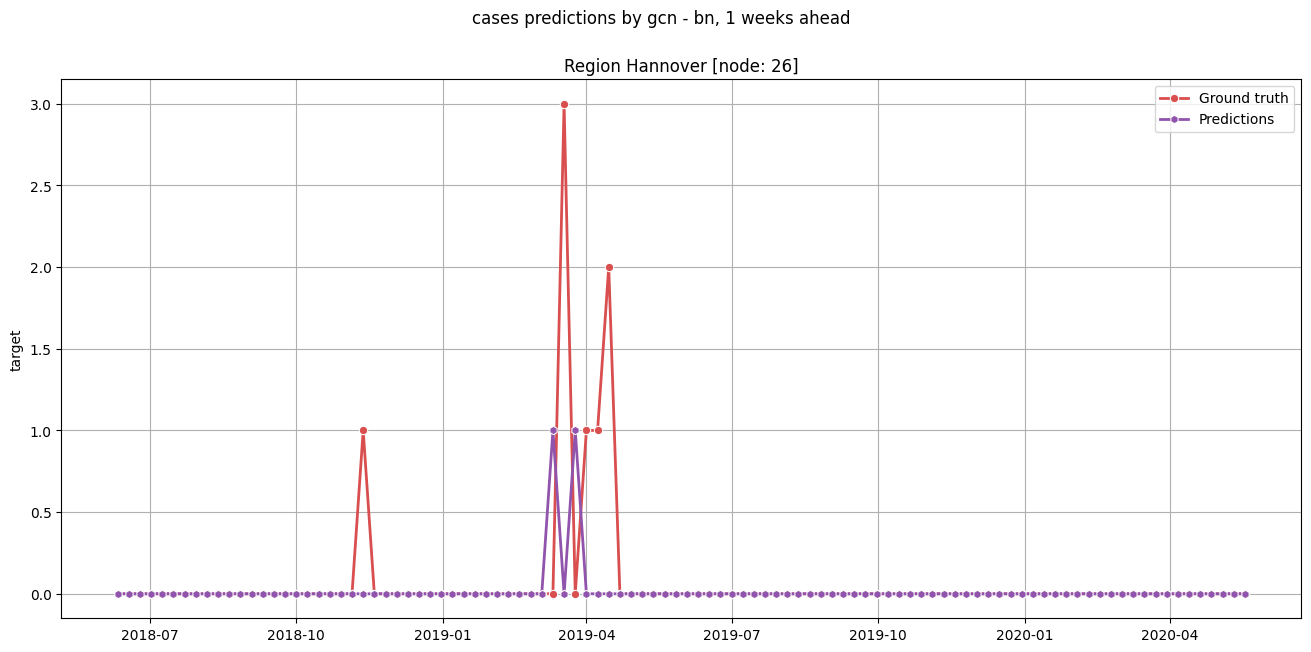

In [5]:
from src.models import SpatialGNNModel

n_epochs        = 25
lr              = 0.0001
min_delta       = 0.0001
loss            = 'poisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


gcn = SpatialGNNModel(graphdataloader_bn, name = 'gcn - bn')
gcn.set_model_hparams()
gcn.set_global_hparams(**global_hparams)
gcn.train(verbose = 2)
gcn.forecast('test')
gcn.show_forecasts(26)


==                   gat - bn                   ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.1322, val loss: 0.1008 ✓ (new best)
Epoch 2 train loss: 0.1167, val loss: 0.1026 (patience: 1/20)
Epoch 3 train loss: 0.1073, val loss: 0.0965 ✓ (new best)
Epoch 4 train loss: 0.1018, val loss: 0.0955 ✓ (new best)
Epoch 5 train loss: 0.0980, val loss: 0.0928 ✓ (new best)
Epoch 6 train loss: 0.0951, val loss: 0.0925 ✓ (new best)
Epoch 7 train loss: 0.0950, val loss: 0.0909 ✓ (new best)
Epoch 8 train loss: 0.0933, val loss: 0.0894 ✓ (new best)
Epoch 9 train loss: 0.0911, val loss: 0.0887 ✓ (new best)
Epoch 10 train loss: 0.0898, val loss: 0.0888 (patience: 1/20)
Epoch 11 train loss: 0.0874, val loss: 0.0874 ✓ (new best)
Epoch 12 train loss: 0.0887, val loss: 0.0894 (patience: 1/20)
Epoch 13 train loss: 0.0868, val loss: 0.0878 (patience: 2/20)
Epoch 14 train loss: 0.0864, val loss: 0.0886 (patience: 3/20)
Epoch 15 t

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 374.13it/s]


Test loss: 0.0720
additonal transformation


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

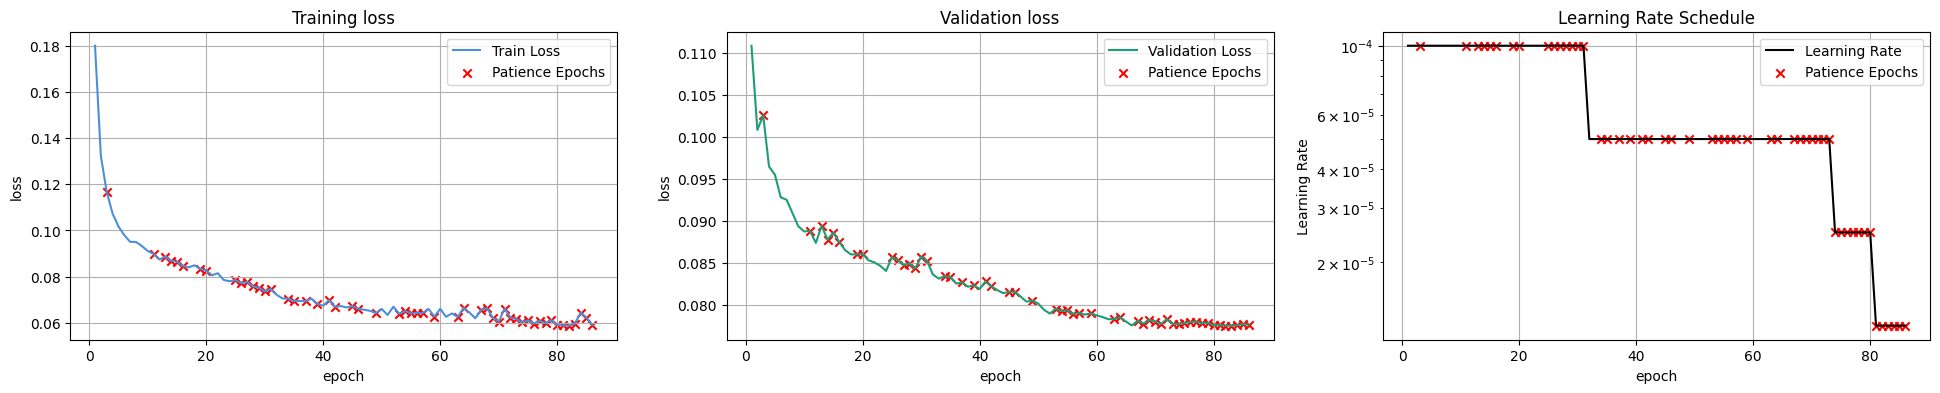

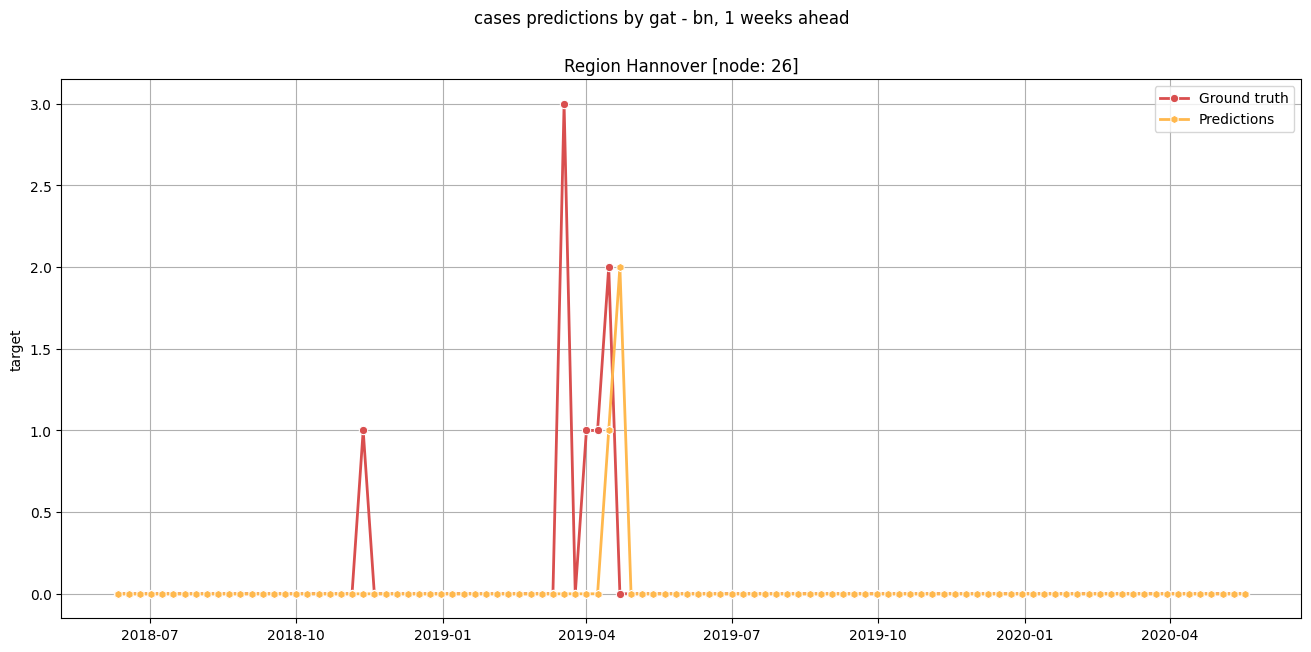

In [6]:
from src.models import GATv2Model

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'poisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


gat = GATv2Model(graphdataloader_bn, name = 'gat - bn')
gat.set_model_hparams()
gat.set_global_hparams(**global_hparams)
gat.train(verbose = 2)
gat.forecast('test')
gat.show_forecasts(26)

(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'SK Oberhausen [node: 69]'}, ylabel='target'>])

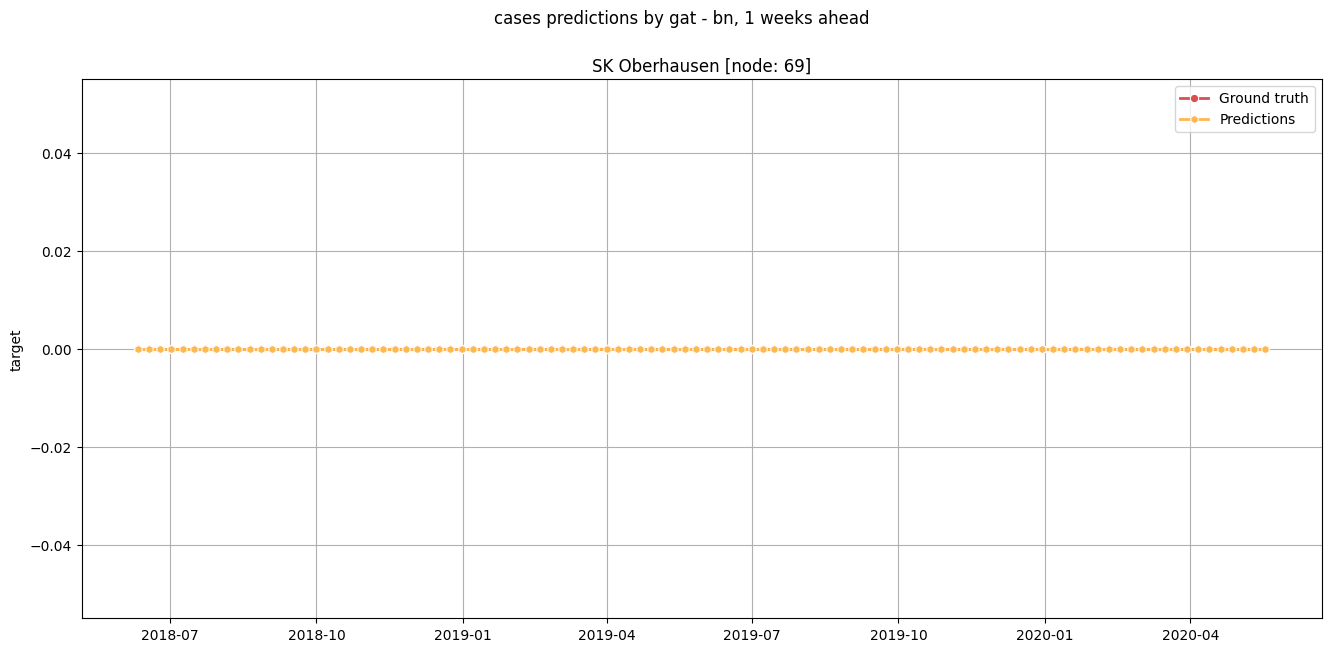

In [7]:
gat.show_forecasts(69)


==                   gcn - bn                   ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.4788, val loss: 0.3423 ✓ (new best)
Epoch 2 train loss: 0.4022, val loss: 0.3227 ✓ (new best)
Epoch 3 train loss: 0.3474, val loss: 0.3122 ✓ (new best)
Epoch 4 train loss: 0.3239, val loss: 0.3085 ✓ (new best)
Epoch 5 train loss: 0.3138, val loss: 0.3074 ✓ (new best)
Epoch 6 train loss: 0.3155, val loss: 0.3068 ✓ (new best)
Epoch 7 train loss: 0.3089, val loss: 0.3058 ✓ (new best)
Epoch 8 train loss: 0.3019, val loss: 0.3051 ✓ (new best)
Epoch 9 train loss: 0.3032, val loss: 0.3044 ✓ (new best)
Epoch 10 train loss: 0.3016, val loss: 0.3036 ✓ (new best)
Epoch 11 train loss: 0.3013, val loss: 0.3031 ✓ (new best)
Epoch 12 train loss: 0.2984, val loss: 0.3025 ✓ (new best)
Epoch 13 train loss: 0.2980, val loss: 0.3019 ✓ (new best)
Epoch 14 train loss: 0.2965, val loss: 0.3013 ✓ (new best)
Epoch 15 train loss: 0.2945, v

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 587.67it/s]


Test loss: 0.2656
additonal transformation


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

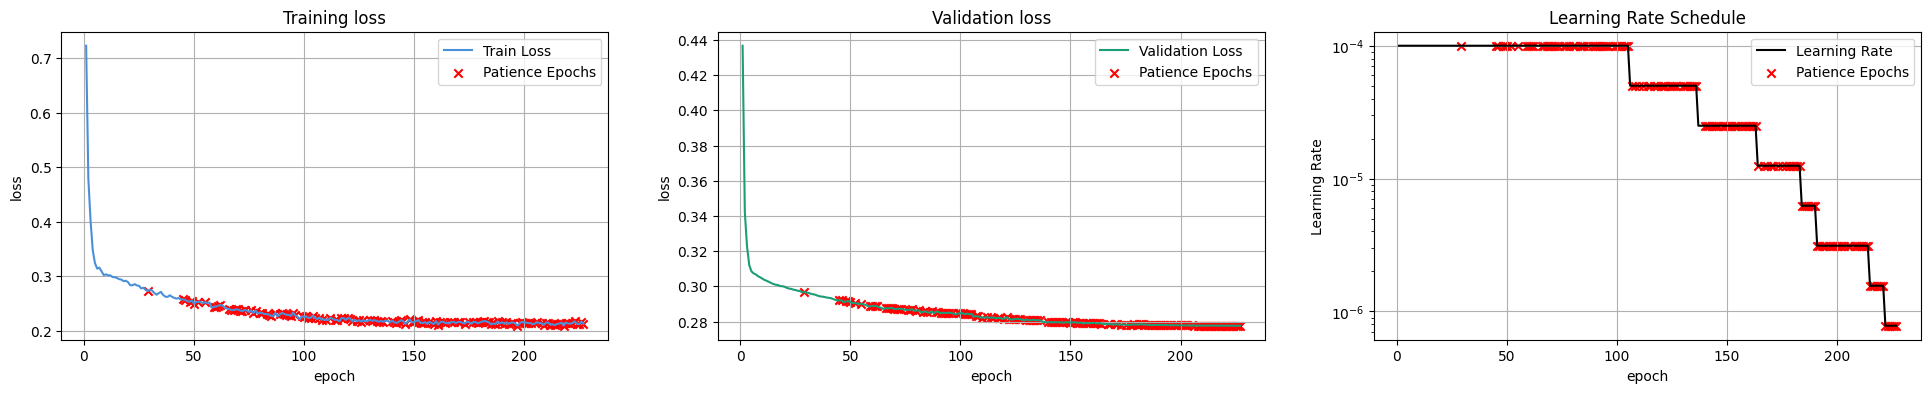

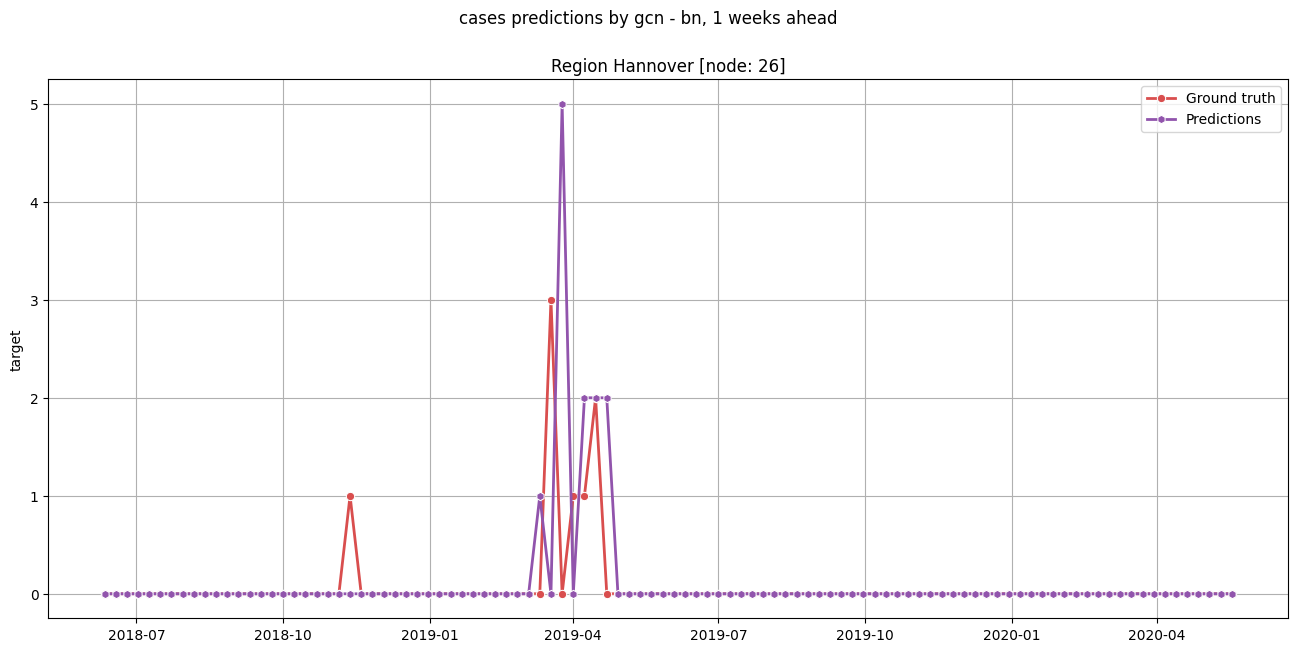

In [8]:
from src.models import SpatialGNNModel

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'outbreakpoisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


gcn = SpatialGNNModel(graphdataloader_bn, name = 'gcn - bn')
gcn.set_model_hparams()
gcn.set_global_hparams(**global_hparams)
gcn.train(verbose = 2)
gcn.forecast('test')
gcn.show_forecasts(26)

(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'SK Hamburg [node: 15]'}, ylabel='target'>])

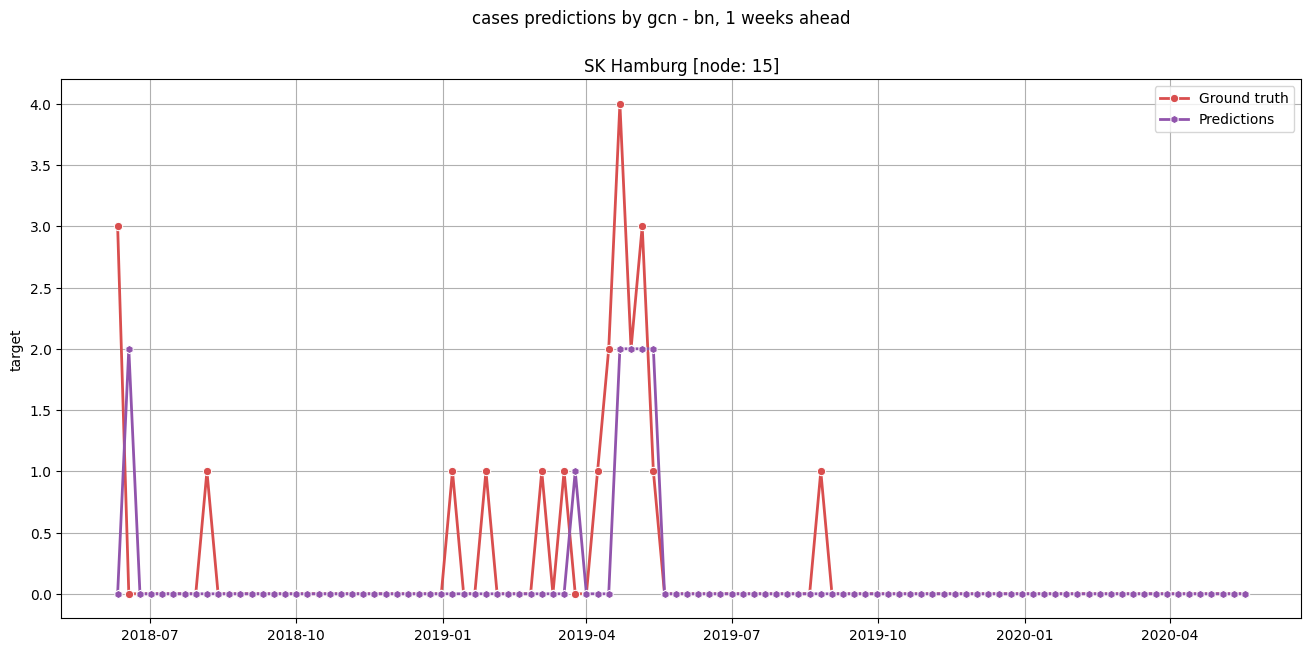

In [9]:
gcn.show_forecasts(15)